In [ ]:
# 1. LOAD CONSOLIDATED DATA FROM GITHUB

import pandas as pd

# Direct Raw link to your GitHub repository folder (Analysis and Modeling)
path = "https://raw.githubusercontent.com/julianevesa/initial-research/main/2_ANALYSIS_MODELING/"

# Load the data directly from GitHub
df = pd.read_csv(path + "base_final_SP.csv", sep=";")

The first step was to open the 2022 Census dataset and examine all available numerical variables at once, without making any initial selections or applying filters. To do this, we ran a simple statistical analysis on all numerical columns to determine the mean, minimum, and maximum values ​​for each, while also checking for missing or zeroed-out data. The goal was to gain an overview of the data and prepare for subsequent steps—using mathematics and correlation tests—to decide which variables truly help explain housing conditions in São Paulo in the context of SDG 11 (Target 1), and which variables could and should be discarded to ensure an accurate analysis free from noise or bias.

In [ ]:
import numpy as np
import pandas as pd

# 1. Filters the dataframe, keeping only the numeric columns
df_num = df.select_dtypes(include=[np.number])

# 2. Creates the basic statistics table
estatistica = df_num.describe().T

estatistica["qtd_nulos"] = df_num.isnull().sum()
estatistica["qtd_zeros"] = (df_num == 0).sum()

display(
    estatistica[
        ["count", "mean", "min", "max", "qtd_nulos", "qtd_zeros"]
    ].round(2)
)

,count,mean,min,max,qtd_nulos,qtd_zeros
CD_MUN,645.0,3528697.88,3500105.0,3557303.0,0,0
v0007,645.0,25180.62,322.0,4316336.0,0,0
V00001,645.0,25149.02,322.0,4307309.0,0,0
V00002,645.0,17.20,0.0,6497.0,0,484
V00003,645.0,176.25,0.0,23985.0,0,191
...,...,...,...,...,...,...
V00640,645.0,291.55,0.0,17478.0,0,32
V00641,645.0,1232.49,0.0,32036.0,0,4
V00642,645.0,288.02,0.0,17948.0,0,33
V00643,645.0,1133.62,0.0,31708.0,0,5


Initial Correlation Analysis

Since the original 2022 Census dataset comprises 644 variables, it is necessary to understand how this information behaves when cross-referenced before making any decisions or creating new rates. The goal of applying a Pearson correlation test at this stage is to identify data points that are redundant or act as a "mirror" of one another.

Performing this check before selecting the final variables is crucial for two reasons: first, the IBGE often repeats the same counts across different tables, and there are variables that present cross-tabulated data—meaning they combine two or more pieces of information in a single column (such as the number of "house" type dwellings where the head of the household is female). Second, if identical variables or those containing such cross-tabulated data are included in the artificial intelligence model, the algorithm will assign double weight to the same subject, thereby skewing the final result. Through this mathematical analysis, we can map all redundancies in a spreadsheet format, allowing us to confidently determine in the next step which columns to keep and which to discard.

In [ ]:
import numpy as np
import pandas as pd

import numpy as np
import pandas as pd

# 1. Calculates the correlation matrix
correlation_matrix = df_num.corr(method="pearson")

# 2. Converts the matrix into a list of pairs
df_pairs = (
    correlation_matrix.where(
        np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
    )
    .stack()
    .reset_index()
)
df_pairs.columns = ["Variable A", "Variable B", "Correlation"]

# 3. Filters strong correlations
threshold = 0.85
df_screening = df_pairs[df_pairs["Correlation"].abs() >= threshold].copy()

# 4. Defines the Relationship Type
df_screening["Relationship Type"] = np.where(
    df_screening["Correlation"] >= threshold,
    "Direct (Same Direction)",
    "Inverse (Mirror)",
)

# 5. Saves the final dataset locally
df_screening = df_screening.sort_values(by="Correlation", ascending=False).round(
    2
)
df_screening.to_csv(
    "initial_variable_correlation_analysis.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False,
)

Definition and Selection of Final Variables

Based on the correlation matrix generated from the initial 643 variables, we made a final selection of the raw columns that were truly relevant to the study. The selection criterion involved eliminating data points that showed perfect correlation (absolute multicollinearity with a value of 1.00) to avoid artificially inflating the weight of any specific topic. For instance, regarding variables V00238 and V00316 (which both measured bathroom facilities but appeared in different IBGE tables), we chose to retain only V00316—which focuses on the total absence of bathroom facilities—and discarded the other. Ultimately, we compiled a dataset comprising raw variables related to basic infrastructure (water, sewage, waste disposal), housing precariousness (tenement housing, dilapidated structures, makeshift dwellings), and social aspects (residents and children), thereby ensuring a clean dataset free of redundant information.

3.4 Justification and Consolidation of Selected Variables

Following automated Pearson correlation tests and a manual qualitative screening process, the dataset was filtered and reduced to the definitive variables comprising the study. This selection was guided by three fundamental criteria: the elimination of statistical redundancies, alignment with the absolute deprivation perspective advocated by the UN for achieving SDG Target 11.1, and a preference for "pure" variables—those representing a single, isolated piece of information.

Discarding variables that combined data points—such as household counts linked specifically to the sex or race of the head of the household—was essential to ensure the model's neutrality. By selecting columns that strictly measure structural or social deficits in isolation (such as the absolute total of households lacking a bathroom or the total number of children), secondary demographic factors are prevented from confounding the measurement of urban precariousness, thereby isolating the phenomenon of interest.

Similarly, variables indicating the presence of adequate infrastructure—such as regular access to the sewage network or "households with exclusive-use bathrooms"—were discarded in favor of those capturing the total absence of service or the reliance on substandard solutions. Statistically, these adequacy variables showed a strong negative correlation with vulnerability variables; conceptually, focusing on absolute deprivation ensures that the artificial intelligence model identifies municipalities based on critical deficits rather than established service coverage. The organization and methodological rationale for the final block of raw variables are detailed below:

1. Population and Territorial Denominators:

V00001 (Occupied Permanent Private Households - DPPO): Retained as the official and exclusive denominator for calculating all urban physical infrastructure rates (water, sewage, waste disposal, bathrooms, and permanent housing types), serving as a comparative baseline to isolate the effect of municipality size.

v0007 (Total Occupied Private Households): Used as an expanded denominator, comprising the sum of permanent and improvised households (DPPO + DPIO); it is applied specifically to calculate indicators of absolute social and housing vulnerability.

2. Social and Demographic Vulnerability Profile:

V00005 and V00008 (Residents and Children aged 0–9 in DPPO): Selected to measure population density and the presence of early childhood populations in permanent structures.

V00006 and V00009 (Residents and Children aged 0–9 in DPIO): Retained to highlight the most critical social scenario, accounting for the number of people and children living in conditions of extreme improvisation.

3. Territorial Vulnerability and Urban Segregation:

N_POP_DPPO (Number of residents in DPPO located in *favelas* and urban communities): This variable was strategically selected to incorporate the dimension of socio-spatial segregation into the model. It identifies the number of residents who, despite living in structures physically classified as permanent, face the territorial vulnerability and urban precariousness typical of *favela* areas. 4. Housing Typologies and Physical Precarity:

V00050, V00051, and V00052 (Tenements, Shacks, and Dilapidated Structures): Retained to represent inadequacies found within the so-called permanent urban fabric (DPPO).

V00053 to V00058 (Tents, Commercial Premises, Natural Shelters, Public Spaces, Non-Residential Structures, and Vehicles): This block of variables regarding improvised dwellings (DPIO) was kept in its entirety for subsequent grouping into a single indicator of extreme housing vulnerability, ensuring that no form of homelessness or substandard housing was omitted.

5. Water Supply Deprivation:

V00113 to V00118 (Alternative Water Sources): Retained to record the use of water without guaranteed prior treatment (shallow wells, springs, water trucks, rainwater, rivers, and reservoirs).

V00200, V00201, and V00464 (External Piping and Lack of Connection): Selected to measure the deficit in internal distribution and the absence of a physical connection to the public utility network.

6. Sanitation and Sewage Deprivation:

V00236 and V00237 (Communal Bathroom and Rudimentary Toilet): Retained as they represent shared usage or structures lacking minimum hygiene standards.

V00312 to V00315 (Inadequate Sewage Disposal): Preserved to cover effluent discharge into rudimentary cesspits, open ditches, and bodies of water.

V00316 (Absolute Absence of Bathroom or Toilet): Retained as the ultimate indicator of sanitation deprivation. The correlation test demonstrated that V00316 exhibited behavior perfectly opposite to that of the variables regarding exclusive bathrooms, justifying the exclusion of the latter in order to focus the model on severe deprivation.

7. Allocation Improper Waste Disposal:

V00399 to V00402 (Waste Burned, Buried, Dumped, or Otherwise Disposed Of): Retained to capture private households outside the regular collection service, whose final waste disposal practices exacerbate local socio-environmental burdens.

In [ ]:
import pandas as pd

# 1. List of deprivation variables (IBGE)
pre_selected_variables = [
    "V00005",
    "V00006",
    "V00008",
    "V00009",
    "N_POP_DPPO",
    "V00050",
    "V00051",
    "V00052",
    "V00053",
    "V00054",
    "V00055",
    "V00056",
    "V00057",
    "V00058",
    "V00113",
    "V00114",
    "V00115",
    "V00116",
    "V00117",
    "V00118",
    "V00200",
    "V00201",
    "V00464",
    "V00236",
    "V00237",
    "V00312",
    "V00313",
    "V00314",
    "V00315",
    "V00316",
    "V00399",
    "V00400",
    "V00401",
    "V00402",
]

# 2. Generates, filters, renames, and rounds the descriptive statistics
df_descriptive = (
    df[pre_selected_variables]
    .describe()
    .T[["count", "mean", "std", "min", "max"]]
    .rename(
        columns={
            "count": "Count",
            "mean": "Mean",
            "std": "Standard Deviation",
            "min": "Minimum",
            "max": "Maximum",
        }
    )
    .round(2)
)

# 3. Saves the header and the table directly to a local TXT file
txt_output = "descriptive_statistics_pre_selection_table.txt"
with open(txt_output, "w", encoding="utf-8") as f:
    f.write(
        "DESCRIPTIVE STATISTICS TABLE (RAW VARIABLES) - PRE-SELECTED.\n\n"
    )
    f.write(df_descriptive.to_string())

# 4. Displays results
display(df_descriptive)

,Count,Mean,Standard Deviation,Minimum,Maximum
V00005,645.0,68385.36,462095.76,907.0,11394071.0
V00006,645.0,54.02,730.33,0.0,18390.0
V00008,645.0,8106.62,52001.38,117.0,1276259.0
V00009,645.0,9.11,138.76,0.0,3493.0
N_POP_DPPO,645.0,5598.84,69436.73,0.0,1717171.0
V00050,645.0,87.84,1194.48,0.0,29855.0
V00051,645.0,0.00,0.00,0.0,0.0
V00052,645.0,11.57,87.00,0.0,1800.0
V00053,645.0,4.86,57.30,0.0,1424.0
V00054,645.0,0.96,13.87,0.0,348.0


An analysis of the descriptive statistics for the 33 raw deprivation variables reveals the socio-spatial heterogeneity characterizing the territory of São Paulo state. The data range is vast: while the municipal resident population (V00005) starts at a minimum of 907 inhabitants, the demographic peak reaches over 11.3 million individuals. This disparity in scale is directly reflected in the standard deviation of most absolute deprivation indicators, where values ​​exceed their respective means by significant orders of magnitude.

Variables associated with critical urban precariousness—such as the population residing in subnormal clusters (N_POP_DPPO) and the total number of households in tenements (*cortiços*, V00050)—show minimum values ​​of zero, suggesting the absence of these phenomena in a large number of small municipalities. Conversely, maximum values ​​reach substantial figures (1,717,171 inhabitants and 29,855 households, respectively), highlighting a strong concentration of extreme housing vulnerability within the state's metropolitan regions and major economic hubs.

Furthermore, the assessment identified that variable V00051 showed a mean, standard deviation, minimum, and maximum of zero across the entire sample set (645 municipalities). Due to the total absence of statistical variance, this metric was deemed irrelevant for predictive modeling or clustering purposes, justifying its discontinuation and exclusion prior to the feature engineering stages.

3.5 Methodological Isolation of Denominators and Descriptive Analysis

To conduct the descriptive statistical analysis and generate the heat map, the variables V00001 (Occupied Permanent Private Households – DPPO) and v0007 (Total Occupied Private Households – DPPO + DPIO) were intentionally isolated and excluded from the correlation tests. Because they function strictly as demographic denominators during the feature engineering stage, these columns measure only the absolute size of the municipalities rather than their structural deficits. Including them at this stage would distort the vulnerability analysis, as their high correlation with all other variables is a logical consequence of population size.

Consequently, the descriptive assessment focused exclusively on the 33 variables representing raw data on absolute deprivation and social profiles. The results confirmed the significant heterogeneity among municipalities in São Paulo state. Minimum and maximum values ​​reveal drastically different orders of magnitude between infrastructure variables and those related to extreme housing vulnerability (such as improvised structures in public spaces); the latter show low averages in most cities but severe peaks concentrated in large urban centers.

TXT file saved to: raw_variables_correlation_list.txt
Plot successfully saved to: raw_variables_correlation_heatmap.png


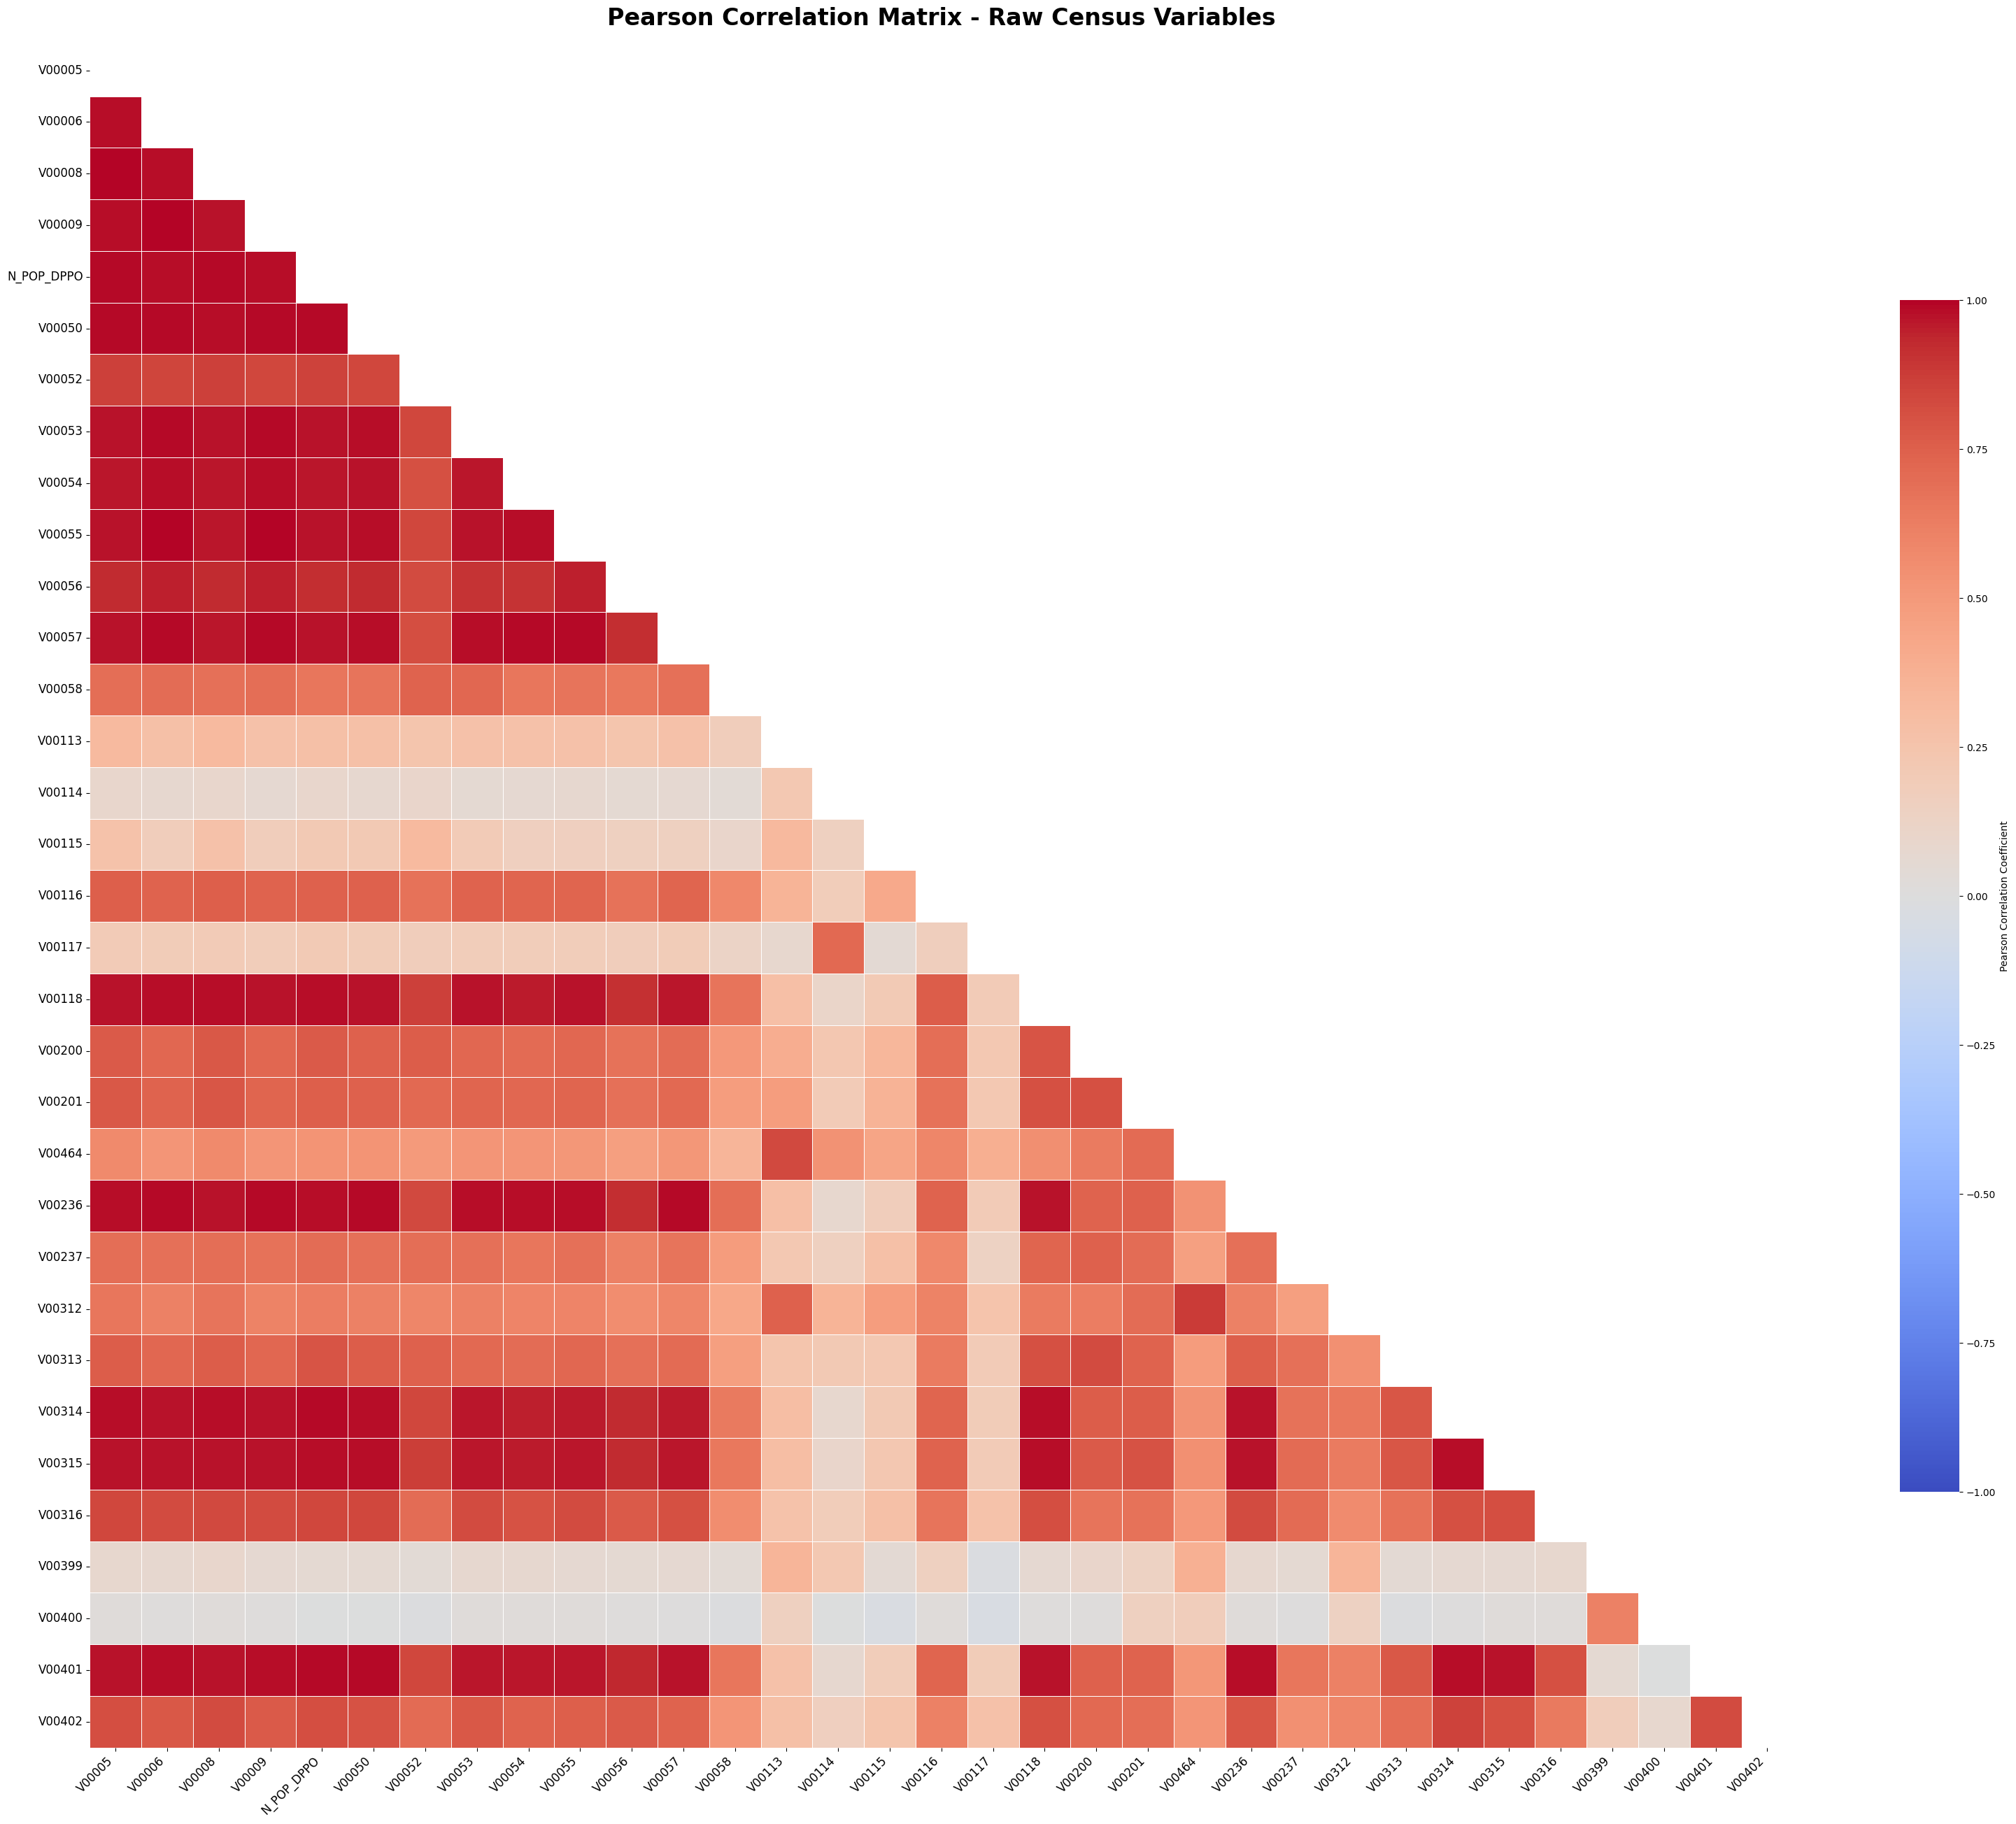

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Filters the variable list removing V00051
filtered_variables = [v for v in pre_selected_variables if v != "V00051"]

# 2. Calculates the correlation matrix
correlation_matrix = df[filtered_variables].corr(method="pearson")

# 3. Extracts, sorts, and formats the correlation pairs
df_pairs = (
    correlation_matrix.where(
        np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
    )
    .stack()
    .reset_index()
)
df_pairs.columns = ["Variable A", "Variable B", "Correlation"]
df_pairs = df_pairs.sort_values(by="Correlation", ascending=False)

# 4. Saves results directly to a local TXT file
txt_output = "raw_variables_correlation_list.txt"
with open(txt_output, "w", encoding="utf-8") as f:
    f.write("=== RAW VARIABLES CORRELATION LIST ===\n")
    f.write("Note: Variable V00051 was removed due to lack of variance.\n\n")
    f.write(
        df_pairs.to_string(
            index=False, formatters={"Correlation": "{:.4f}".format}
        )
    )

print(f"TXT file saved to: {txt_output}")

# 5. Configures and generates the Heatmap
plt.figure(figsize=(32, 26))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(
    correlation_matrix,
    mask=mask,
    cmap="coolwarm",
    vmax=1.0,
    vmin=-1.0,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.7, "label": "Pearson Correlation Coefficient"},
)

plt.title(
    "Pearson Correlation Matrix - Raw Census Variables",
    fontsize=24,
    fontweight="bold",
    pad=20,
)
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()

# 6. Saves and displays the plot locally
plot_output = "raw_variables_correlation_heatmap.png"
plt.savefig(plot_output, dpi=300, bbox_inches="tight")
print(f"Plot successfully saved to: {plot_output}")

plt.show()

3.6 The Demographic Scale Phenomenon: Why Raw Data Obscure Reality?

A detailed mathematical analysis of the correlation matrix for raw variables revealed a statistical pattern demanding extreme methodological caution. As evidenced by the list of Pearson coefficients, nearly all absolute variables regarding urban deprivation exhibit extraordinarily high linear associations, with values ​​frequently exceeding the $0.95$ threshold.

At first glance, a cursory reading might suggest that variables such as the total number of households lacking a private bathroom, the population living in slums, and the volume of substandard housing share an absolute conceptual redundancy. However, scientific analysis points to a classic statistical bias in population studies: the Demographic Scale Effect.

In practical terms, large municipalities (such as the metropolises of São Paulo state) record—by sheer mathematical logic—massive absolute volumes across all census counts simultaneously. A large metropolis will concentrate more households, more children, more sewage networks, and, inevitably, a higher raw number of tenements and substandard dwellings. Conversely, municipalities with small populations will record counts close to zero across virtually all economic and structural indicators.

When these population extremes are cross-referenced using absolute data, the correlation coefficient ceases to measure the actual intensity or social nature of vulnerability and instead measures solely the municipality's population size. The graphical result of this phenomenon is a heat map homogeneously saturated with shades indicating strong positive correlation (a "sea of ​​blue"), which masks the territory's true dynamics of deprivation.

Empirical evidence for this diagnosis emerges when analyzing the lower end of the correlation list, where the scale effect loses its dominance and structural geographic disparities come to light. Variables such as the presence of *cortiços* (tenements) and extreme urban poverty showed a near-zero (and sometimes negative) correlation when cross-referenced with sewage disposal via rudimentary septic tanks. This phenomenon occurs because rudimentary septic tanks are a predominant feature in rural areas or small inland towns, whereas tenements and high-density *favelas* are typically metropolitan phenomena. When population scale is weighed against the actual geographic distribution of the issue, the illusion of perfect correlations dissolves.

Feeding these raw absolute figures directly into Artificial Intelligence algorithms or machine learning clustering models would yield scientifically invalid results. The mathematical models would be misled, merely classifying municipalities into a linear ranking of "Large Cities vs. Small Cities" while failing to identify severe pockets of proportional destitution in smaller municipalities. Therefore, to neutralize the influence of population size and ensure a fair, symmetrical, and scientifically rigorous basis for comparing heterogeneous territories, transitioning to the feature engineering phase becomes mathematically essential. In this subsequent stage, isolated demographic denominators (V00001 and v0007) will be used to normalize the raw counts, transforming absolute volumes into proportional rates of deprivation per household and per inhabitant.

In [ ]:
import pandas as pd

# 1. List of household variables
household_variables = [
    "V00006",
    "V00009",
    "V00050",
    "V00052",
    "V00053",
    "V00054",
    "V00055",
    "V00056",
    "V00057",
    "V00113",
    "V00114",
    "V00115",
    "V00116",
    "V00117",
    "V00118",
    "V00200",
    "V00201",
    "V00236",
    "V00237",
    "V00312",
    "V00313",
    "V00314",
    "V00315",
    "V00316",
    "V00399",
    "V00400",
    "V00401",
    "V00402",
    "V00464",
]

# 2. Calculates all household rates simultaneously
df_rates = df[household_variables].div(df["v0007"], axis=0) * 100
df_rates.columns = [f"{var}_P" for var in household_variables]

# 3. Adds the special case for population percentage
df_rates["N_POP_DPPO_P"] = (df["N_POP_DPPO"] / df["V00005"]) * 100

# 4. Inserts identifiers at the beginning of the DataFrame
df_rates.insert(0, "CD_MUN", df["CD_MUN"].values)
df_rates.insert(1, "NM_MUN", df["NM_MUN"].values)

if "NM_UF" in df.columns:
    df_rates.insert(2, "NM_UF", df["NM_UF"].values)
if "CD_UF" in df.columns:
    df_rates.insert(3, "CD_UF", df["CD_UF"].values)

# 5. Generates the descriptive statistics table
rates_descriptive = (
    df_rates.describe()
    .T[["count", "mean", "std", "min", "max"]]
    .rename(
        columns={
            "count": "Count",
            "mean": "Mean (%)",
            "std": "Standard Deviation",
            "min": "Minimum (%)",
            "max": "Maximum (%)",
        }
    )
    .round(2)
)

# 6. Saves the descriptive statistics table directly to a local TXT file
txt_output = "selected_variables_rates_statistics_table.txt"
with open(txt_output, "w", encoding="utf-8") as f:
    f.write(
        "DESCRIPTIVE STATISTICS TABLE (PROPORTIONS WITH UNIFIED DENOMINADOR v0007)\n"
    )
    f.write(
        "All housing variables deflated by Total Occupied Households.\n\n"
    )
    f.write(rates_descriptive.to_string())

# 7. Displays results
display(rates_descriptive)

,Count,Mean (%),Standard Deviation,Minimum (%),Maximum (%)
CD_MUN,645.0,3528697.88,16700.33,3500105.0,3557303.00
V00006_P,645.0,0.15,0.56,0.0,9.69
V00009_P,645.0,0.02,0.08,0.0,1.53
V00050_P,645.0,0.07,0.18,0.0,1.77
V00052_P,645.0,0.01,0.06,0.0,0.60
V00053_P,645.0,0.03,0.20,0.0,3.83
V00054_P,645.0,0.00,0.02,0.0,0.30
V00055_P,645.0,0.01,0.05,0.0,0.86
V00056_P,645.0,0.00,0.01,0.0,0.19
V00057_P,645.0,0.00,0.02,0.0,0.41


After converting the raw data into percentages, the new descriptive table reveals a much more balanced and realistic picture of vulnerability in the state of São Paulo. By using the Total Occupied Households as the sole denominator for housing variables, the effect of city size was eliminated, allowing for a fair comparison between small and large municipalities.

The results indicate that, although the average rate for most forms of urban deprivation is low (often below 1%), there are municipalities where the situation is critical. The V00464_P indicator, for instance, shows a state average of 10.52% but reaches an alarming peak of 74.17% in a single locality. Similar patterns of intense local concentration appear in variables V00312_P (maximum of 55.73%) and V00114_P (maximum of 47.46%), highlighting severe pockets of substandard conditions that were previously masked by absolute figures.

Additionally, the analysis revealed that variable V00058_P consistently showed a value of zero across all statistics (mean, minimum, and maximum of 0.00%). Due to the complete lack of variation across the state of São Paulo, this metric was deemed irrelevant; it will be excluded from the dataset prior to training the Artificial Intelligence models, alongside the previously discontinued variable.

Analyzing the unified percentage rates relative to the total number of occupied households (v0007) made it possible to identify the true scale of housing deprivation in the state of São Paulo, free from distortions caused by city size. Overall, state averages for most extreme vulnerabilities are low, indicating that scenarios of severe housing precariousness are not the norm across the state's territory.

However, the maximum values ​​reveal profound regional inequality and raise critical red flags for public policy. The most severe case involves variable V00464_P: while the state average for households lacking a water connection is 10.52%, one municipality shows an alarming rate of 74.17%. Severe inequalities were also found regarding sanitation; one city recorded 55.73% of households discharging sewage into rudimentary cesspits (V00312_P), while another showed 47.46% reliance on shallow wells or open pits (V00114_P).

Finally, the data confirmed that variable V00058_P remained at zero across the entire state. Due to this complete lack of variation, it will be discarded to optimize the dataset used to train the artificial intelligence algorithms. Conversely, variable V00056_P—despite showing very low values ​​(with a maximum of just 0.19%)—will be retained in the study. Although statistically small, this metric serves as an indicator of a rare event (a social anomaly), carrying significant qualitative weight that will help the model identify municipalities with very specific scenarios of extreme street-level vulnerability.

TXT file successfully saved to: final_rates_correlation_list.txt
Plot successfully saved to: final_rates_correlation_heatmap.png


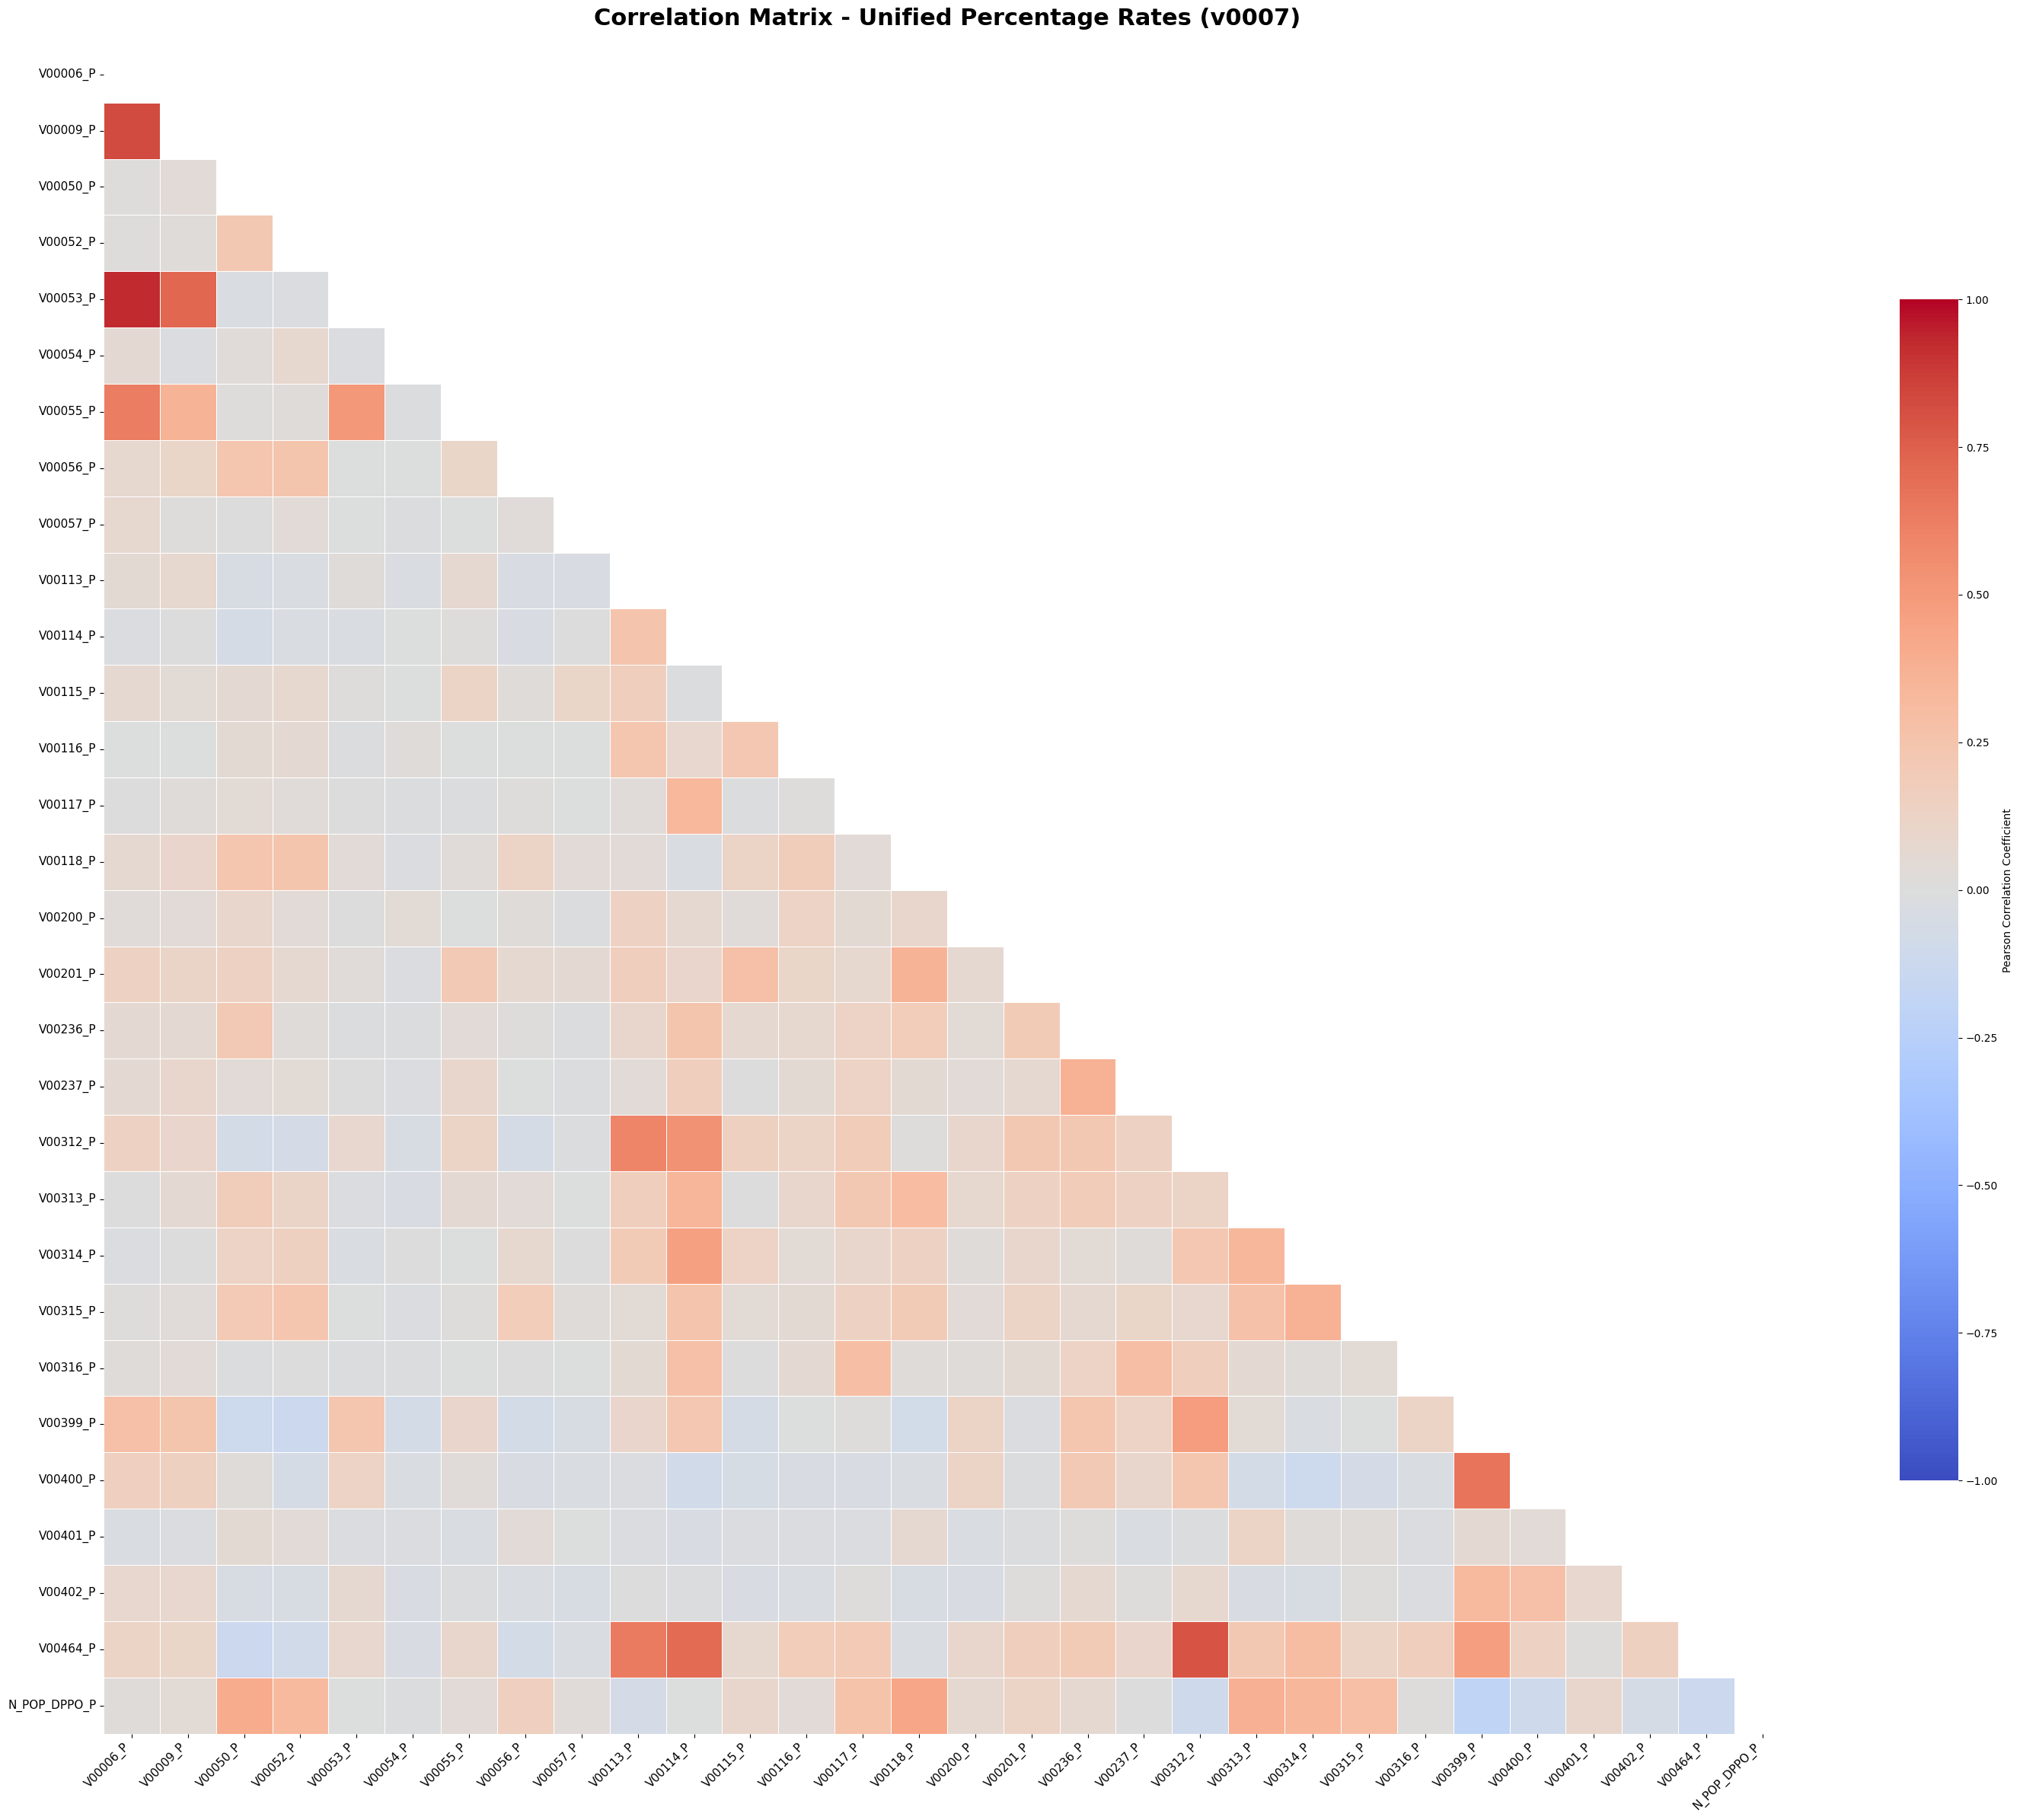

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Selects columns ending with '_P' and removes 'V00058_P'
final_rates = [
    t for t in df_rates.columns if t.endswith("_P") and t != "V00058_P"
]

# 2. Calculates the new correlation matrix for rates
rates_correlation_matrix = df_rates[final_rates].corr(method="pearson")

# 3. Extracts and sorts correlation pairs
df_pairs = (
    rates_correlation_matrix.where(
        np.triu(np.ones(rates_correlation_matrix.shape), k=1).astype(bool)
    )
    .stack()
    .reset_index()
)
df_pairs.columns = ["Variable A", "Variable B", "Correlation"]
df_pairs = df_pairs.sort_values(by="Correlation", ascending=False)

# 4. Saves the correlation list directly to a local TXT file
txt_output = "final_rates_correlation_list.txt"
with open(txt_output, "w", encoding="utf-8") as f:
    f.write("CORRELATION LIST FOR PERCENTAGE RATES (v0007)\n")
    f.write(
        "Analysis of real relationships after removing the demographic scale effect.\n\n"
    )
    f.write(
        df_pairs.to_string(
            index=False, formatters={"Correlation": "{:.4f}".format}
        )
    )

print(f"TXT file successfully saved to: {txt_output}")

# 5. Configures and generates the Heatmap
plt.figure(figsize=(30, 24))
mask = np.triu(np.ones_like(rates_correlation_matrix, dtype=bool))

sns.heatmap(
    rates_correlation_matrix,
    mask=mask,
    cmap="coolwarm",
    vmax=1.0,
    vmin=-1.0,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.7, "label": "Pearson Correlation Coefficient"},
)

plt.title(
    "Correlation Matrix - Unified Percentage Rates (v0007)",
    fontsize=22,
    fontweight="bold",
    pad=20,
)
plt.xticks(rotation=45, ha="right", fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()

# 6. Saves and displays the plot locally
plot_output = "final_rates_correlation_heatmap.png"
plt.savefig(plot_output, dpi=300, bbox_inches="tight")
print(f"Plot successfully saved to: {plot_output}")

plt.show()

The transition from the correlation matrix of raw variables to the matrix of percentage rates revealed a significant structural shift in data behavior. While the matrix of raw selected data displayed artificially high coefficients—driven by the demographic scale of the municipalities—the matrix generated from proportions (using the denominator v0007: Total Occupied Households) showed a predominantly neutral profile, with values ​​close to zero. This overall disconnect indicates that housing and infrastructure deprivations in the state of São Paulo do not occur homogeneously or linearly across the territory. However, the few linear correlations that remained significant reveal the true axes of associated vulnerability—where different dimensions of urban poverty structurally coexist within the same municipality—offering valuable insights to be explored by clustering algorithms and artificial intelligence.

An analysis of the coefficients that survived demographic filtering revealed clear, inseparable axes of structural vulnerability. The most critical cluster relates to extreme housing precarity and homelessness, evidenced by the very strong correlation between the proportion of residents in makeshift dwellings (V00006_P) and the presence of tents or shacks in public spaces (V00053_P, r = 0.9284). This scenario is exacerbated by the strong association of these indicators with the number of children aged zero to nine living in such conditions (V00009_P, r = 0.8206), delineating areas of severe social exclusion.

A second structural axis emerges regarding basic sanitation and network infrastructure. A strong convergence is observed between the lack of connection to the public water supply network (V00464_P) and the disposal of sewage into rudimentary septic tanks or open pits (V00312_P, r = 0.7921)—a pattern also directly linked to a reliance on shallow wells or dug wells (V00114_P, r = 0.7063). This pattern indicates a historical infrastructure deficit that tends to be concentrated within the same municipalities.

Finally, the correlation between the population residing in subnormal clusters (N_POP_DPPO_P)—informal settlements—and reliance on alternative water supplies (V00118_P, r = 0.4351) and *cortiço*-style tenements (V00050_P, r = 0.4053) indicates that the phenomenon of *favelas* in the state of São Paulo is characterized by consolidated and dense precarity, distinguishing it from profiles of scattered vulnerability or absolute street-based homelessness. These remaining linear axes validate the relevance of the selected variables and provide the framework of patterns that Artificial Intelligence algorithms will use to segment municipal profiles.

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 1. Filters columns ending with "_P"
rate_columns = [c for c in df_rates.columns if c.endswith("_P")]

# 2. Instantiates MinMaxScaler and applies transformation
df_rates_normalized = pd.DataFrame(
    MinMaxScaler().fit_transform(df_rates[rate_columns]),
    columns=rate_columns,
    index=df_rates.index,
)

# 3. Saves the final normalized dataset locally
df_rates_normalized.to_csv("df_rates_normalized.csv", encoding="utf-8")

# 4. Displays the first few rows for verification
display(df_rates_normalized.head())

,V00006_P,V00009_P,V00050_P,V00052_P,V00053_P,V00054_P,V00055_P,V00056_P,V00057_P,V00113_P,...,V00313_P,V00314_P,V00315_P,V00316_P,V00399_P,V00400_P,V00401_P,V00402_P,V00464_P,N_POP_DPPO_P
0,0.003799,0.0,0.024943,0.0,0.0,0.0,0.0,0.0,0.0,0.008373,...,0.000000,0.000000,0.000000,0.0,0.018375,0.018875,0.0,0.094383,0.037613,0.0
1,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.021339,...,0.000000,0.000000,0.000000,0.0,0.048288,0.000000,0.0,0.000000,0.093155,0.0
2,0.003596,0.0,0.068860,0.0,0.0,0.0,0.0,0.0,0.0,0.051891,...,0.000000,0.000000,0.041220,0.0,0.093439,0.027914,0.0,0.220052,0.078787,0.0
3,0.018225,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.011477,...,0.000000,0.079387,0.106359,0.0,0.030947,0.000000,0.0,0.026634,0.120928,0.0
4,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.009561,...,0.005317,0.008937,0.018986,0.0,0.010547,0.000000,0.0,0.008321,0.049974,0.0


It is crucial to highlight the methodological distinction and complementarity between data proportionalization and subsequent linear scaling normalization (Min-Max scaling). Applying the Min-Max algorithm directly to raw Census data would be both insufficient and incorrect; while normalization adjusts the geometric range of variables to an interval between 0 and 1, it preserves distortions caused by the municipalities' demographic scales. Without first dividing the data by the total number of occupied households (v0007), Artificial Intelligence algorithms would be biased by absolute population sizes—grouping municipalities based on population volume rather than the severity of their housing deprivations.

Therefore, data transformation was carried out in two mandatory, independent stages: first, proportionalization (division by the unified denominator v0007) was performed to eliminate the effect of city size and convert absolute counts into rates of deprivation intensity. Next, Min-Max normalization was applied to equalize the weight of different variables within the geometric clustering model, ensuring that indicators with historically low averages (such as extreme homelessness) held the same potential influence as indicators with higher prevalence (such as sanitation deficits). This two-tiered approach shields the model from biases related to demographic scale and variable magnitude, thereby ensuring the statistical accuracy of the clustering process.

The decision to apply the K-Means algorithm directly to the normalized rates was a deliberate methodological choice aimed at preserving the interpretability and analytical transparency of the results. Determining the optimal number of partitions (K) was supported by the mathematical criteria of the Elbow Method (Inertia) and the Silhouette Coefficient, ensuring the formation of clusters that are internally homogeneous and maximally distinct from one another.

Although PCA is effective for reducing data volume, it transforms the original Census variables into abstract orthogonal components; this would make it impossible to directly and individually identify which infrastructure deficits (such as the exact percentage of water shortages or inadequate sanitation) shape each cluster. Given that this study aims to inform urban planning and the targeting of specific public policies, retaining the variables in their original form ensures that the clusters generated by the Artificial Intelligence maintain immediate empirical alignment with the physical and social reality of the municipalities in São Paulo state, without any loss of sociological meaning.

Plot successfully saved to: elbow_silhouette_selection_plot.png


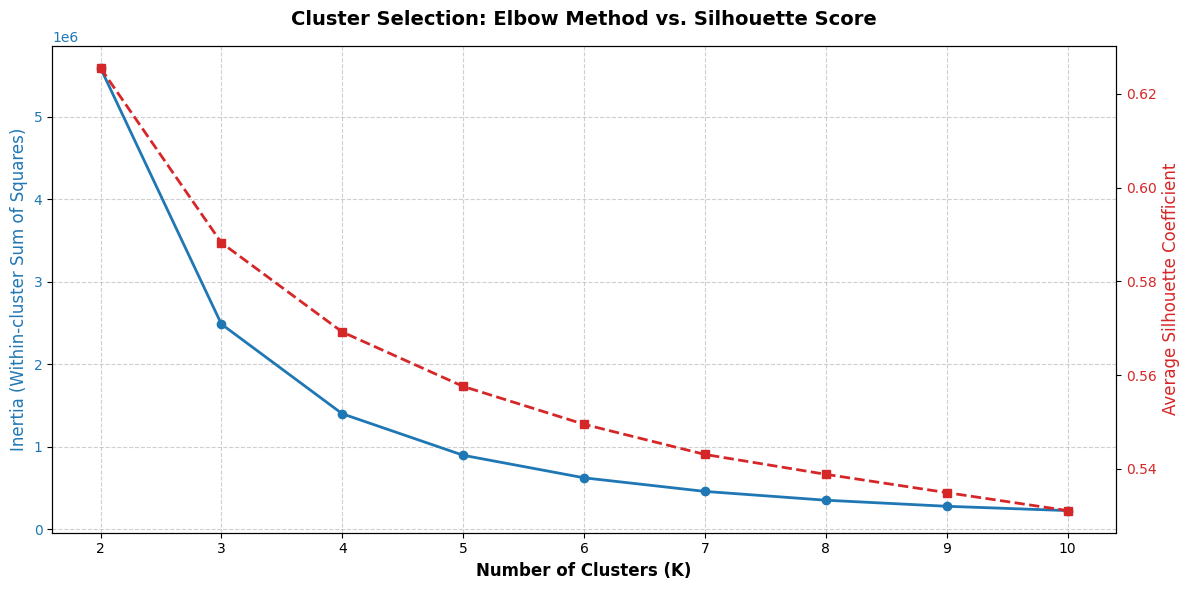

,K (Clusters),Inertia,Silhouette
0,2,5.590478e+06,0.6256
1,3,2.484803e+06,0.5882
2,4,1.397796e+06,0.5692
3,5,8.948773e+05,0.5576
4,6,6.214509e+05,0.5495
5,7,4.566588e+05,0.5430
6,8,3.499397e+05,0.5388
7,9,2.765238e+05,0.5349
8,10,2.242048e+05,0.5311


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load normalized data locally
df_filtered = pd.read_csv("df_rates_normalized.csv")

# 1. Initialize lists for metrics
inertias = []
silhouette_scores = []
k_range = range(2, 11)

# 2. Run K-Means across the range of K values
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_filtered)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_filtered, labels))

# 3. Generate dual plot (Elbow vs. Silhouette)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Inertia Plot (Elbow Method) - Left Axis (Blue)
ax1.set_xlabel("Number of Clusters (K)", fontsize=12, fontweight="bold")
ax1.set_ylabel("Inertia (Within-cluster Sum of Squares)", color="tab:blue", fontsize=12)
ax1.plot(k_range, inertias, marker="o", color="tab:blue", linewidth=2)
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, linestyle="--", alpha=0.6)

# Silhouette Score Plot - Right Axis (Red)
ax2 = ax1.twinx()
ax2.set_ylabel("Average Silhouette Coefficient", color="tab:red", fontsize=12)
ax2.plot(k_range, silhouette_scores, marker="s", color="tab:red", linewidth=2, linestyle="--")
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title(
    "Cluster Selection: Elbow Method vs. Silhouette Score",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
fig.tight_layout()

# 4. Save and display the plot locally
plot_output = "elbow_silhouette_selection_plot.png"
plt.savefig(plot_output, dpi=300, bbox_inches="tight")
print(f"Plot successfully saved to: {plot_output}")
plt.show()

# 5. Display numerical results
df_metrics = pd.DataFrame({"K (Clusters)": k_range, "Inertia": inertias, "Silhouette": silhouette_scores}).round(4)
display(df_metrics)

✨ Variables chosen for the plot: 'V00312_P' (X-Axis) and 'V00464_P' (Y-Axis)
Plot successfully saved to: clusters_scatter_plot.png


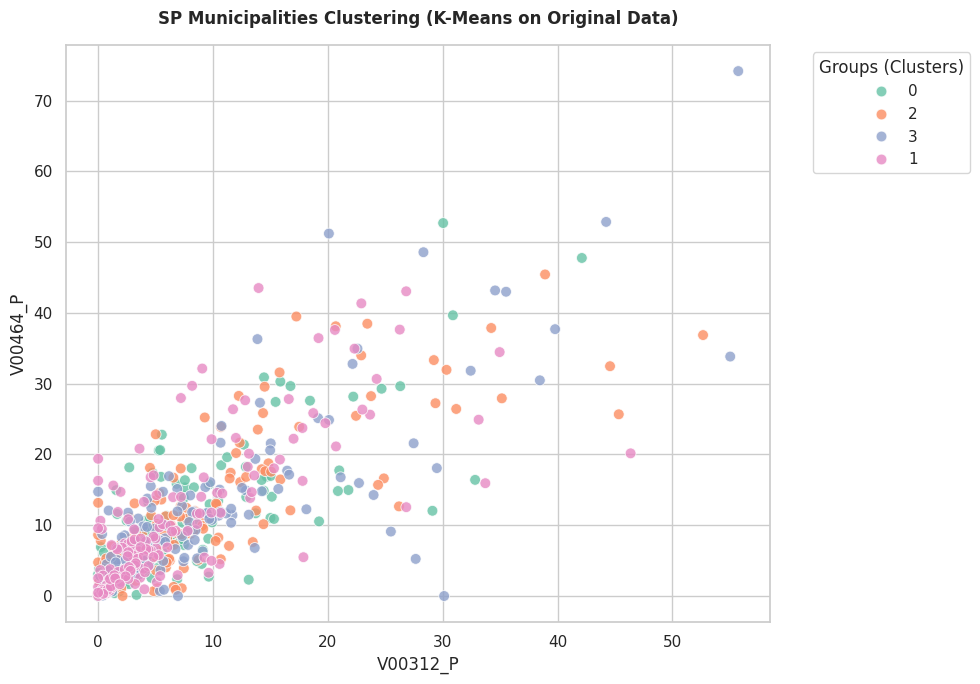


=== MUNICIPALITY DISTRIBUTION ===
Cluster
0    162
2    162
3    161
1    160
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans

# 1. Load normalized data locally
df_filtered = pd.read_csv("df_rates_normalized.csv")

# 2. Run definitive K-Means (K=4)
df_filtered["Cluster"] = (
    KMeans(n_clusters=4, random_state=42, n_init=10)
    .fit_predict(df_filtered)
    .astype(str)
)

# 3. Link back to the original rates dataset and save locally
df_final_results = df_rates.copy()
df_final_results["Cluster"] = df_filtered["Cluster"]
df_final_results.to_csv(
    "final_cluster_results.csv", encoding="utf-8", index=False
)

# 4. Save Cluster Statistical Profile to a local TXT file
txt_output = "cluster_statistical_profile.txt"
with open(txt_output, "w", encoding="utf-8") as f:
    f.write("      CLUSTER PROFILE   \n")
    f.write("=== MUNICIPALITY DISTRIBUTION ===\n")
    f.write(df_final_results["Cluster"].value_counts().to_string() + "\n\n")
    f.write("=== DETAILED PROFILE BY VARIABLE (%) ===\n")
    f.write(
        df_final_results.groupby("Cluster")
        .describe()
        .T.loc[(slice(None), ["mean", "50%", "std"]), :]
        .to_string()
    )

# 5. Automatic selection of the top two variables for plotting
df_numeric = df_final_results.select_dtypes(include=["number"])
columns_to_ignore = [
    "CD_MUN",
    "Cluster",
    "ID",
    "Codigo",
    "Município",
    "Municipio",
]

analysis_columns = [
    col
    for col in df_numeric.columns
    if col not in columns_to_ignore and df_final_results[col].nunique() > 10
]

top_vars = (
    df_final_results.groupby("Cluster")[analysis_columns]
    .mean()
    .std()
    .nlargest(2)
    .index
)
var_x = top_vars[0]
var_y = top_vars[1]

print(
    f"✨ Variables chosen for the plot: '{var_x}' (X-Axis) and '{var_y}' (Y-Axis)"
)

# 6. Configure and generate the scatter plot
plt.figure(figsize=(10, 7))
sns.set_theme(style="whitegrid")

sns.scatterplot(
    data=df_final_results,
    x=var_x,
    y=var_y,
    hue="Cluster",
    palette="Set2",
    alpha=0.8,
    s=60,
    edgecolor="w",
)

plt.title(
    "SP Municipalities Clustering (K-Means on Original Data)",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel(var_x)
plt.ylabel(var_y)
plt.legend(title="Groups (Clusters)", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

# 7. Save and display the plot locally
plot_output = "clusters_scatter_plot.png"
plt.savefig(plot_output, dpi=300, bbox_inches="tight")
print(f"Plot successfully saved to: {plot_output}")
plt.show()

print("\n=== MUNICIPALITY DISTRIBUTION ===")
print(df_final_results["Cluster"].value_counts())

# 📑 Dictionary of Selected Variables — SDG Target 11.1 (2022 Census)

This dictionary presents the final selection of variables from the 2022 Demographic Census (IBGE) used in the urban vulnerability modeling. The methodological strategy consisted of isolating demographic denominators and retaining **only variables indicative of deficit, deprivation, or inadequacy**, ensuring a unique and consistent directionality for Principal Component Analysis (PCA) and Clustering ($K$-Means).

---

### 1. Control Variables and Denominators (Methodological Weights)
* **`CD_MUN`**: Official municipality identification code (7 digits - IBGE).
* **`V00001`**: Occupied Permanent Private Households *(Physical Infrastructure Denominator)*.
* **`V00007`**: Total Occupied Private Households (Permanent + Improvised) *(Absolute Vulnerability Denominator)*.
* **`V00005`**: Number of residents in Occupied Permanent Private Households.
* **`V00006`**: Number of residents in Occupied Improvised Private Households.
* **`V00008`**: Number of children aged 0 to 9 in Occupied Permanent Private Households.
* **`V00009`**: Number of children aged 0 to 9 in Occupied Improvised Private Households.
* **`N_POP_DPPO`**: Resident population in slums and urban communities *(Aggregated external variable)*.

---

### 2. Raw Housing and Demographic Inadequacy Variables
* **`V00050`**: Housing in a tenement or boarding house room.
* **`V00051`**: Indigenous housing without walls or communal hut (*maloca*).
* **`V00052`**: Degraded or unfinished permanent residential structure.
* **`V00053`**: Improvised household: tent or shack made of canvas, plastic, or fabric.
* **`V00054`**: Improvised household: inside an operating commercial or industrial establishment.
* **`V00055`**: Improvised household: natural shelter and other improvised structures.
* **`V00056`**: Improvised household: improvised structure in a public space (excluding tents/shacks).
* **`V00057`**: Improvised household: degraded or unfinished permanent non-residential structure.
* **`V00058`**: Improvised household: vehicle (car, truck, trailer, boat, etc.).

---

### 3. Raw Water Inadequacy Variables
* **`V00113`**: Water supply from a shallow well, water table, or hand-dug well (*cacimba*).
* **`V00114`**: Water supply from a spring or fountain.
* **`V00115`**: Water supply from a water tanker truck.
* **`V00116`**: Water supply from stored rainwater.
* **`V00117`**: Water supply from rivers, reservoirs, streams, lakes, and channels (*igarapés*).
* **`V00118`**: Other precarious form of water supply.
* **`V00200`**: Piped water is available, but only to the land/yard.
* **`V00201`**: Piped water does not reach the household at all.
* **`V00463`**: Connected to the general water supply network, but primarily uses another source *(Intermittency)*.
* **`V00464`**: Household has no connection to the general water distribution network *(Exclusion)*.

---

### 4. Raw Sanitation Inadequacy Variables (Sewage and Restrooms)
* **`V00236`**: Only a restroom shared by more than one household *(Tenements/Collective housing)*.
* **`V00237`**: Only a toilet pit or hole for waste (including those located on the land).
* **`V00312`**: Sewage disposal into a rudimentary cesspool or pit.
* **`V00313`**: Sewage disposal into an open ditch.
* **`V00314`**: Sewage disposal into a river, lake, stream, or sea (direct discharge).
* **`V00315`**: Other inadequate form of sewage disposal.
* **`V00316`**: Non-existent sewage disposal due to lack of restroom or toilet facilities *(Extreme Deprivation)*.

---

### 5. Raw Waste Management Variables (Garbage)
* **`V00399`**: Garbage burned on the property.
* **`V00400`**: Garbage buried on the property.
* **`V00401`**: Garbage dumped in a vacant lot, hillside, or public area.
* **`V00402`**: Other inadequate form of garbage disposal.

---

> 💡 **Methodological Note on Exclusion:**
> * Water comfort and socioeconomic stratification variables (**V00232 to V00235** and **V00485 to V00494** - count of multiple restrooms) were eliminated because they do not represent deprivation.
> * Full service and urban coverage variables (**V00111, V00112, V00199, V00309, V00310, V00311, V00397, and V00398**) were discarded to suppress the statistical noise of reverse multicollinearity (*mirror effect*) in the covariance matrix.
> * Variable **V00238** (absence of a restroom) was removed due to perfect multicollinearity and mathematical tautology with variable **V00316** (non-existent disposal due to lack of restroom), choosing to retain the latter in the corresponding block.

In [ ]:
import pandas as pd
import plotly.express as px
from sklearn.cluster import KMeans

# 1. Define the number of clusters
N_CLUSTERS_3D = 4

# 2. Select columns ending with "_P"
df_filtered_normalized = df_rates_normalized[
    [c for c in df_rates_normalized.columns if c.endswith("_P")]
].copy()

# Run definitive K-Means directly on normalized data
df_filtered_normalized["Cluster"] = (
    KMeans(n_clusters=N_CLUSTERS_3D, random_state=42, n_init=10)
    .fit_predict(df_filtered_normalized)
    .astype(str)
)

# 3. Automatic selection of the top three variables for the 3D plot
columns_to_ignore = [
    "CD_MUN",
    "Cluster",
    "ID",
    "Codigo",
    "Município",
    "Municipio",
]

analysis_columns = [
    col
    for col in df_filtered_normalized.columns
    if col not in columns_to_ignore and df_filtered_normalized[col].nunique() > 10
]

top_vars = (
    df_filtered_normalized.groupby("Cluster")[analysis_columns]
    .mean()
    .std()
    .nlargest(3)
    .index
)
var_x = top_vars[0]
var_y = top_vars[1]
var_z = top_vars[2]

print(
    f"✨ Variables selected for the 3D plot:\nX: '{var_x}'\nY: '{var_y}'\nZ: '{var_z}'"
)

# 4. Generates the interactive 3D scatter plot
df_plot_3d = df_rates.copy()
df_plot_3d["Cluster"] = df_filtered_normalized["Cluster"]

fig = px.scatter_3d(
    df_plot_3d,
    x=var_x,
    y=var_y,
    z=var_z,
    color="Cluster",
    color_discrete_sequence=px.colors.qualitative.Set2,
    title=f"3D Spatial Visualization of SP Municipalities (K = {N_CLUSTERS_3D} Clusters - No PCA)",
)

# Esthetic adjustments for thesis quality
fig.update_traces(
    marker=dict(size=4, opacity=0.7, line=dict(width=0.5, color="White"))
)
fig.update_layout(
    margin=dict(l=0, r=0, b=0, t=40),
    width=900,
    height=700,
    legend=dict(title="Clusters"),
)

# 5. Displays and saves the plot locally
fig.show()

html_output = f"interactive_3d_plot_k{N_CLUSTERS_3D}.html"
fig.write_html(html_output)

print(f"👍 Interactive 3D plot successfully saved to: {html_output}")

✨ Variables selected for the 3D plot:
X: 'N_POP_DPPO_P'
Y: 'V00312_P'
Z: 'V00114_P'


👍 Interactive 3D plot successfully saved to: interactive_3d_plot_k4.html


In [ ]:
#!pip install geobr geopandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.0/338.0 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 57.6 MB/s eta 0:00:00
  Attempting uninstall: shapely
    Found existing installation: shapely 2.1.2
    Uninstalling shapely-2.1.2:
      Successfully uninstalled shapely-2.1.2
  Attempting uninstall: lxml
    Found existing installation: lxml 6.1.1
    Uninstalling lxml-6.1.1:
      Successfully uninstalled lxml-6.1.1
  Attempting uninstall: geopandas
    Found existing installation: geopandas 1.1.3
    Uninstalling geopandas-1.1.3:
      Successfully uninstalled geopandas-1.1.3


📥 Downloading SP municipal mesh from IBGE... Please wait.

✅ Success! 645 municipalities geometrically linked via CD_MUN.
Map successfully saved to: sp_clusters_map.png


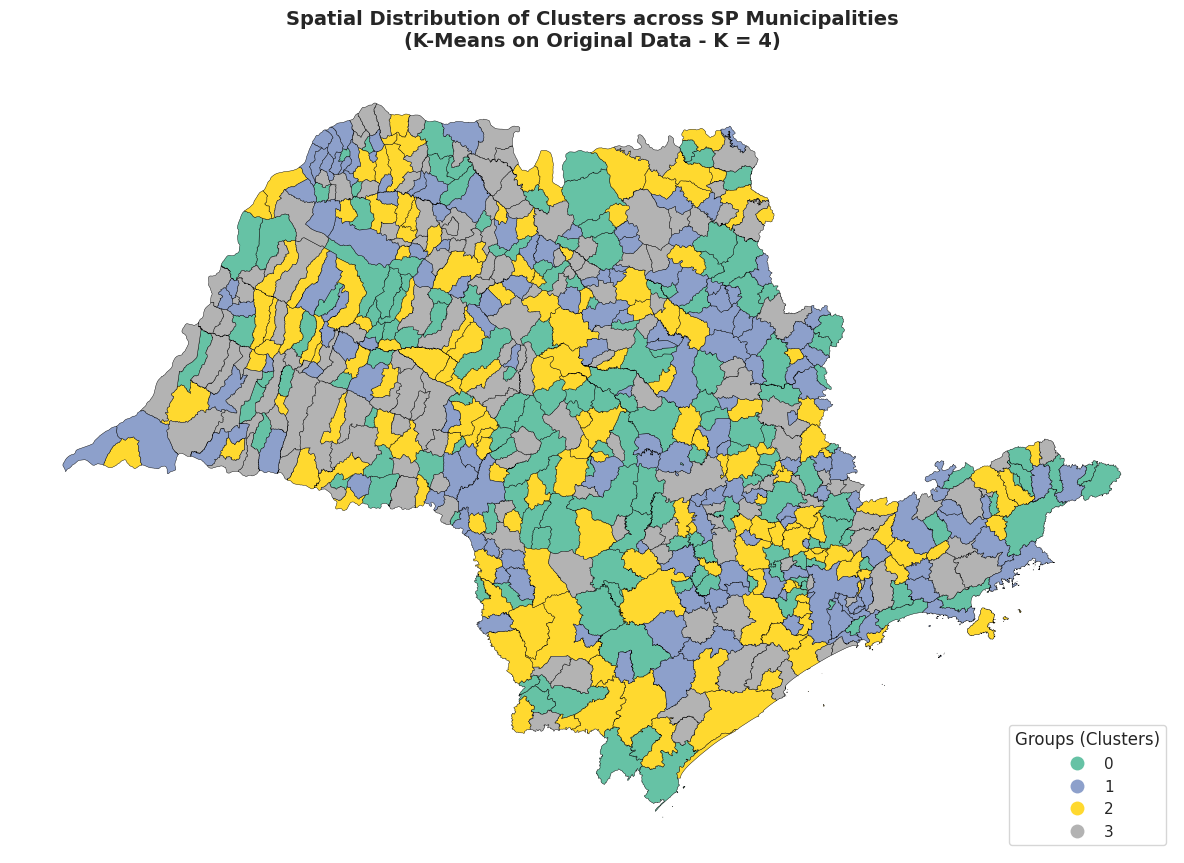

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

# 1. Load the original base from GitHub
path = "https://raw.githubusercontent.com/julianevesa/initial-research/main/2_ANALYSIS_MODELING/"
df_original_base = pd.read_csv(path + "base_final_SP.csv", sep=";")

# 2. Load the updated local cluster results
df_results = pd.read_csv("final_cluster_results.csv")

# 3. Align municipality codes based on row order
df_results["CD_MUN"] = df_original_base["CD_MUN"].values

# 4. Download official municipality shapefile directly from IBGE
print("📥 Downloading SP municipal mesh from IBGE... Please wait.")
sp_mesh = gpd.read_file(
    "https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/malhas_municipais/municipio_2022/UFs/SP/SP_Municipios_2022.zip"
)

# 5. Standardize join keys as strings
sp_mesh["CD_MUN"] = sp_mesh["CD_MUN"].astype(str).str.strip()
df_results["CD_MUN"] = df_results["CD_MUN"].astype(str).str.strip()

# 6. Merge geographic data with cluster results
map_data = sp_mesh.merge(df_results, on="CD_MUN", how="left")

# Handle missing values before forcing categorical ordering
map_data["Cluster"] = map_data["Cluster"].fillna("-1").astype(str)

cluster_categories = sorted([c for c in map_data["Cluster"].unique() if c != "-1"])
municipalities_with_data = map_data[map_data["Cluster"] != "-1"].copy()
municipalities_with_data["Cluster"] = pd.Categorical(
    municipalities_with_data["Cluster"], categories=cluster_categories, ordered=True
)

municipalities_without_data = map_data[map_data["Cluster"] == "-1"]

if len(municipalities_with_data) == 0:
    print("\n❌ ERROR: Merge failed. Please check if municipality codes have 7 digits.")
else:
    print(f"\n✅ Success! {len(municipalities_with_data)} municipalities geometrically linked via CD_MUN.")

    # 7. Configure and plot the choropleth map
    fig, ax = plt.subplots(figsize=(12, 10))

    # Plot municipalities with cluster data
    municipalities_with_data.plot(
        column="Cluster",
        cmap="Set2",
        legend=True,
        legend_kwds={
            "title": "Groups (Clusters)",
            "loc": "lower right",
        },
        edgecolor="black",
        linewidth=0.3,
        ax=ax,
    )

    # Plot background for municipalities without data
    if len(municipalities_without_data) > 0:
        municipalities_without_data.plot(
            color="#e0e0e0", edgecolor="black", linewidth=0.3, ax=ax
        )

    # Fine-tuning for academic visualization
    plt.title(
        "Spatial Distribution of Clusters across SP Municipalities\n(K-Means on Original Data - K = 4)",
        fontsize=14,
        fontweight="bold",
        pad=15,
    )
    ax.set_axis_off()
    plt.tight_layout()

    # 8. Save and display the map locally
    plot_output = "sp_clusters_map.png"
    plt.savefig(plot_output, dpi=300, bbox_inches="tight")
    print(f"Map successfully saved to: {plot_output}")

    plt.show()

In [ ]:
import pandas as pd

# PANDAS CONFIGURATION: Force full display without truncating rows
pd.set_option("display.max_rows", None)

# 1. Load the local cluster results
df_results = pd.read_csv("final_cluster_results.csv")

# 2. Automatically select rate columns (ending in _P) and the Cluster column
rate_columns = [c for c in df_results.columns if c.endswith("_P")]
df_rates_cluster = df_results[rate_columns + ["Cluster"]]

# 3. CENTROID PROFILE CONSTRUCTION (Updated for 4 groups: 0, 1, 2, and 3)
df_centroids_real = df_rates_cluster.groupby("Cluster").mean().T
df_centroids_real.columns = [
    "Cluster_0_Mean",
    "Cluster_1_Mean",
    "Cluster_2_Mean",
    "Cluster_3_Mean",
]

# 4. MULTICLUSTER SORTING CRITERION (Intergroup Disparity)
mean_columns = [
    "Cluster_0_Mean",
    "Cluster_1_Mean",
    "Cluster_2_Mean",
    "Cluster_3_Mean",
]
df_centroids_real["Intergroup_Disparity"] = df_centroids_real[
    mean_columns
].std(axis=1)

# Sort the report in descending order based on the magnitude of disparity
df_centroids_real = df_centroids_real.sort_values(
    by="Intergroup_Disparity", ascending=False
)

# 5. Save the final centroids analysis dataset locally
df_centroids_real.to_csv("centroids_analysis_4_clusters.csv", encoding="utf-8")

# 6. TRANSLATION DICTIONARY (International Demographic Standard)
legend_dict_en = {
    "V00001_P": "OPPD - Proportion of Occupied Permanent Private Dwellings",
    "v0007_P": "Total Occupied Private Dwellings (OPPD + OPID)",
    "V00005_P": "OPPD - Average number of residents",
    "V00008_P": "OPPD - Proportion of children aged 0 to 9",
    "V00006_P": "OPID - Average number of residents",
    "V00009_P": "OPID - Proportion of children aged 0 to 9",
    "V00050_P": "OPPD Type - Rooming house or tenement (cortiço)",
    "V00051_P": "OPPD Type - Indigenous housing without walls (maloca)",
    "V00052_P": "OPPD Type - Degraded or unfinished residential structure",
    "V00053_P": "OPID Type - Tent or canvas/plastic/fabric shack",
    "V00054_P": "OPID Type - Located within an operating commercial establishment",
    "V00055_P": "OPID Type - Natural shelter and other structures",
    "V00056_P": "OPID Type - Improvised structure in public spaces/streets",
    "V00057_P": "OPID Type - Degraded or unfinished non-residential structure",
    "V00058_P": "OPID Type - Vehicle (car, truck, trailer, boat, etc.)",
    "V00113_P": "OPPD Water - Uses shallow well, water table, or cistern",
    "V00114_P": "OPPD Water - Uses natural spring, source, or mine",
    "V00115_P": "OPPD Water - Uses water tank truck (carro-pipa)",
    "V00116_P": "OPPD Water - Uses stored rainwater",
    "V00117_P": "OPPD Water - Uses rivers, lakes, streams, or ponds",
    "V00118_P": "OPPD Water - Uses other forms of water supply",
    "V00200_P": "OPPD Water - Piped water, but only to the property/land",
    "V00201_P": "OPPD Water - No piped water supply directly to the dwelling",
    "V00236_P": "OPPD Bathroom - Shared use bathroom/toilet facility",
    "V00237_P": "OPPD Bathroom - Basic pit latrine or makeshift toilet structure",
    "V00312_P": "OPPD Sewage - Rudimentary pit or cesspool",
    "V00313_P": "OPPD Sewage - Open ditch / Open-air sewage",
    "V00314_P": "OPPD Sewage - Discharged directly into rivers, lakes, streams, or sea",
    "V00315_P": "OPPD Sewage - Other forms of wastewater disposal",
    "V00316_P": "OPPD Sewage - Inexistent (no bathroom or toilet facility)",
    "V00399_P": "OPPD Waste - Burned within the property",
    "V00400_P": "OPPD Waste - Buried within the property",
    "V00401_P": "OPPD Waste - Disposed of in vacant lots, hillsides, or public areas",
    "V00402_P": "OPPD Waste - Other destination given to waste",
    "V00464_P": "OPPD Water - No connection to the general water distribution network",
    "N_POP_DPPO_P": "Proportion of Resident Population in Favelas / Informal Settlements",
}

# 7. FORMATTED TABLE DISPLAY
print(
    f"=== CENTROID PROFILES ({len(df_centroids_real)} Variables Translated and Sorted by Intergroup Disparity) ==="
)

# Apply English translation mapping and horizontal gradient
final_table_en = (
    df_centroids_real.rename(index=legend_dict_en)
    .round(4)
    .style.background_gradient(cmap="Blues", axis=1, subset=mean_columns)
)

# Render formatted table
display(final_table_en)

# Reset Pandas row display configuration to default
pd.reset_option("display.max_rows")

=== CENTROID PROFILES (30 Variables Translated and Sorted by Intergroup Disparity) ===


,Cluster_0_Mean,Cluster_1_Mean,Cluster_2_Mean,Cluster_3_Mean,Intergroup_Disparity
OPPD Sewage - Rudimentary pit or cesspool,6.783000,7.129300,8.558600,8.825900,1.018100
OPPD Water - No connection to the general water distribution network,9.319300,10.674800,11.079200,11.022600,0.822800
Proportion of Resident Population in Favelas / Informal Settlements,1.213100,1.361900,1.301100,0.473200,0.413900
OPPD Waste - Burned within the property,3.105100,2.968000,3.633700,3.531200,0.322900
"OPPD Water - Uses natural spring, source, or mine",2.966300,3.215300,2.725200,2.620800,0.265200
"OPPD Water - Uses shallow well, water table, or cistern",1.392500,1.859500,1.871300,1.906100,0.244000
"OPPD Water - Piped water, but only to the property/land",0.345100,0.157100,0.206000,0.259500,0.080500
OPPD Sewage - Open ditch / Open-air sewage,0.246100,0.179500,0.264100,0.127600,0.062800
"OPPD Sewage - Discharged directly into rivers, lakes, streams, or sea",0.757400,0.837200,0.790000,0.733500,0.044900
OPPD Waste - Other destination given to waste,0.295400,0.384700,0.301600,0.355900,0.043200


### Municipality Group Analysis ($K$-Means, $K=4$)

Analysis of the Census data reveals that infrastructure deficits and vulnerability in São Paulo vary **from municipality to municipality** rather than from region to region. Because the four groups contain nearly the same number of municipalities (~161 cities each), it is clear that the state is divided into four highly distinct urban realities.

Spatial mapping indicates that neighboring cities can exhibit completely different urban structures. This demonstrates that sanitation and housing conditions are heavily dependent on local government decisions and historical municipal contexts, rather than the geographic macro-region in which the city is located.

### Detailed Profile of Each Cluster

#### Cluster 3: Cities with Infrastructure Excellence (161 municipalities)
This group concentrates the finest urban indicators in the state.
* **Near-Zero Vulnerability:** It registers the lowest rate of residents living in slums ($N\_POP\_DPPO\_P = 0.47\%$) and an almost non-existent population in improvised households.
* **Comprehensive Sanitation:** The indices for open-air sewage or reliance on precarious cesspools are the lowest in the state.
* **Secure Housing:** Tenements ($V00050\_P$) or degraded/unfinished dwellings are virtually non-existent within this group.

#### Cluster 0: Cities in Transition or Rural Areas (162 municipalities)
Typically comprised of small towns or territories situated in the transition zone between rural and urban environments. Infrastructure has begun to arrive, but it has not yet been fully integrated within households.
* **Water Access Restricted to the Plot:** The primary bottleneck here is the variable $V00200\_P$ ($0.34\%$). This indicates that while piped water reaches the property lot, it has not yet been plumbed into the house itself.
* **Reliance on Decentralized Solutions:** Residents rely more heavily on shallow or artesian wells ($V00113\_P = 1.39\%$) for their water supply because the centralized public network does not span the entire territory.

#### Cluster 1: Cities with Housing Deficits and Overcrowding (160 municipalities)
This group isolates municipalities suffering from a lack of quality housing stock and a high prevalence of precarious dwellings.
* **Prevalence of Tenements:** It exhibits the state's highest average for tenement-style housing or single-room boarding houses ($V00050\_P = 0.081\%$).
* **Unfinished Dwellings:** This cluster leads in abandoned or poorly constructed structures ($V00052\_P = 0.021\%$) and shacks made of canvas or plastic ($V00053\_P = 0.037\%$).
* **Shared Restrooms:** Residents endure a severe lack of private facilities, recording the highest use of shared restrooms or highly rudimentary toilet pits ($V00237\_P$).

#### Cluster 2: Cities with Sanitation and Waste Management Bottlenecks (162 municipalities)
The defining issue for this group is the critical deficit in basic sewerage services and public sanitation.
* **Sewage Crisis:** This is the group where populations rely most on rudimentary or unlined cesspools ($V00312\_P = 8.55\%$) or discharge raw sewage directly into open ditches ($V00313\_P = 0.26\%$).
* **Backyard Waste Burning:** Due to weak or absent public refuse collection, this cluster shows the highest rate of domestic waste being burned within properties ($V00399\_P = 3.63\%$).
* **Exposed Children:** This cluster registers the highest percentage of children aged 0 to 9 living in improvised households ($V00009\_P = 0.025\%$).

### Conclusion and Policy Implications

The findings prove that inequality in São Paulo must be tackled through **tailored, municipality-by-municipality interventions**.

This study demonstrates that policy priorities must shift based on the specific bottleneck: while **Cluster 1** cities urgently require housing programs and slum-upgrading initiatives, **Cluster 2** cities require heavy structural engineering investments (sewer networks and solid waste management infrastructure). This clear division refutes generalized macro-regional planning and instead advocates for resource allocation targeted directly at each municipality's precise deficit.

**Methodological Note on Rate Magnitudes:** While the percentage averages of these vulnerability indicators appear numerically low (frequently below 5%), this magnitude reflects the historical reality of the State of São Paulo, which possesses one of the most consolidated infrastructure networks in the country. Statistically, the fact that the $K$-Means algorithm successfully isolates and groups these subtle variances proves its high sensitivity in detecting residual bottlenecks to universal access.

Furthermore, two critical factors must be considered: first, the dilution effect inherent to sample means (where severe spikes in isolated cities are smoothed out by the group average); and second, the absolute demographic weight. In large-scale municipalities belonging to these clusters, seemingly residual rates of 2% or 3% translate into thousands of citizens exposed to substandard housing and precarious sanitation conditions.